Phân tích tác động của COVID-19 đến kinh tế vĩ mô và thị trường lao động tại Việt Nam giai đoạn 2000–2025

- Đại dịch COVID-19 đã tác động như thế nào đến tăng trưởng GDP và tỷ lệ thất nghiệp tại Việt Nam?
- Mức độ giãn cách xã hội (Stringency Index) trong giai đoạn COVID-19 có ảnh hưởng như thế nào đến tăng trưởng kinh tế và thị trường lao động?
- Đại dịch COVID-19 có tạo ra structural break đối với các chỉ số kinh tế vĩ mô của Việt Nam hay không?
- Nền kinh tế Việt Nam đã phục hồi như thế nào sau cú sốc COVID-19 giai đoạn 2020–2021?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from statsmodels.formula.api import ols

# style
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

In [ ]:
df = pd.read_csv('../../data/processed/merged_dataset.csv')

print(df.shape)
print(df.describe())
df.head()

Tăng trưởng GDP của Việt Nam trong giai đoạn COVID-19

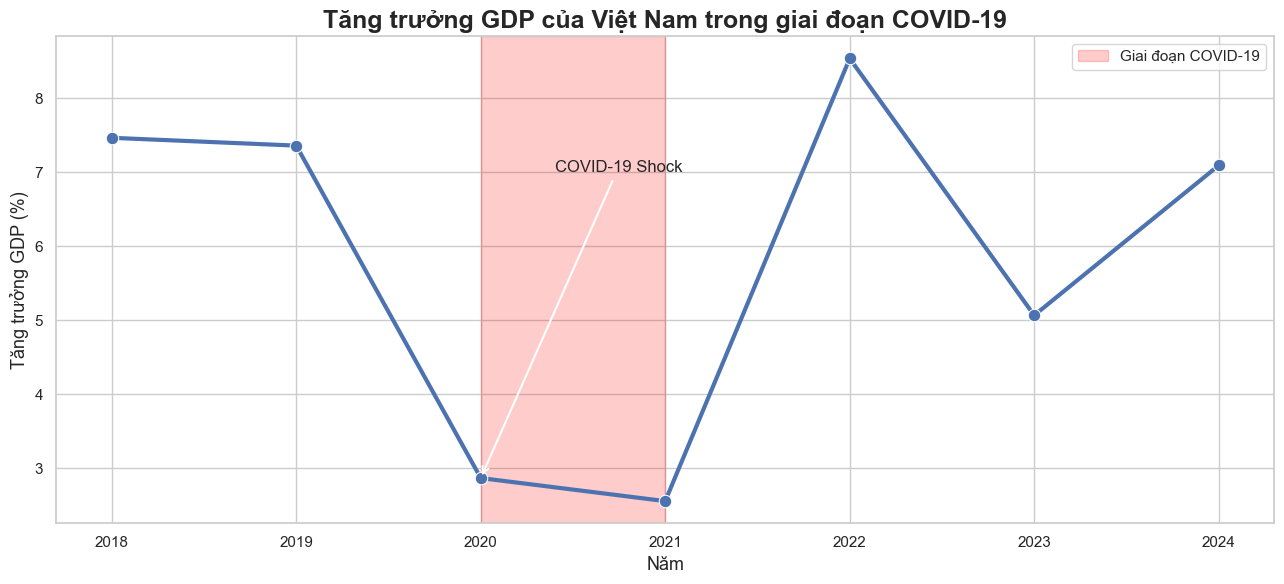

In [ ]:
covid_df = df[
    (df['year'] >= 2018) &
    (df['year'] <= 2024)
].copy()

plt.figure(figsize=(13,6))

sns.lineplot(
    data=covid_df,
    x='year',
    y='gdp_growth',
    marker='o',
    linewidth=3,
    markersize=9
)

# Highlight
plt.axvspan(
    2020,
    2021,
    alpha=0.2,
    color='red',
    label='Giai đoạn COVID-19'
)

# Annotation
plt.annotate(
    'COVID-19 Shock',
    xy=(
        2020,
        covid_df.loc[
            covid_df['year'] == 2020,
            'gdp_growth'
        ].values[0]
    ),
    xytext=(2020.4, 7),
    arrowprops=dict(arrowstyle='->', lw=1.5)
)

plt.title(
    'Tăng trưởng GDP của Việt Nam trong giai đoạn COVID-19',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Năm')
plt.ylabel('Tăng trưởng GDP (%)')
plt.xticks(covid_df['year'])
plt.legend()
plt.tight_layout()
plt.show()

Giai đoạn 2020–2021 cho thấy sự suy giảm rõ rệt của tăng trưởng GDP Việt Nam dưới tác động của đại dịch COVID-19. Tăng trưởng GDP giảm mạnh từ mức trên 7% trước đại dịch xuống khoảng 2–3% trong giai đoạn cao điểm COVID-19, phản ánh cú sốc tiêu cực đối với nền kinh tế.

Sự suy giảm này chủ yếu đến từ các biện pháp giãn cách xã hội, hạn chế di chuyển và gián đoạn chuỗi cung ứng, khiến hoạt động sản xuất, tiêu dùng và thương mại bị ảnh hưởng đáng kể. Dù Việt Nam kiểm soát dịch bệnh tương đối hiệu quả trong giai đoạn đầu, nền kinh tế vẫn chịu tác động từ sự suy giảm nhu cầu toàn cầu và sự đình trệ sản xuất trong nước.

Sau năm 2022, GDP tăng trở lại, cho thấy dấu hiệu phục hồi của nền kinh tế nhờ quá trình mở cửa trở lại, phục hồi xuất khẩu và hoạt động đầu tư. Tuy nhiên, tăng trưởng GDP giai đoạn hậu COVID vẫn còn biến động, cho thấy nền kinh tế chưa hoàn toàn ổn định như trước đại dịch.

Tỷ lệ thất nghiệp của Việt Nam trong giai đoạn COVID-19

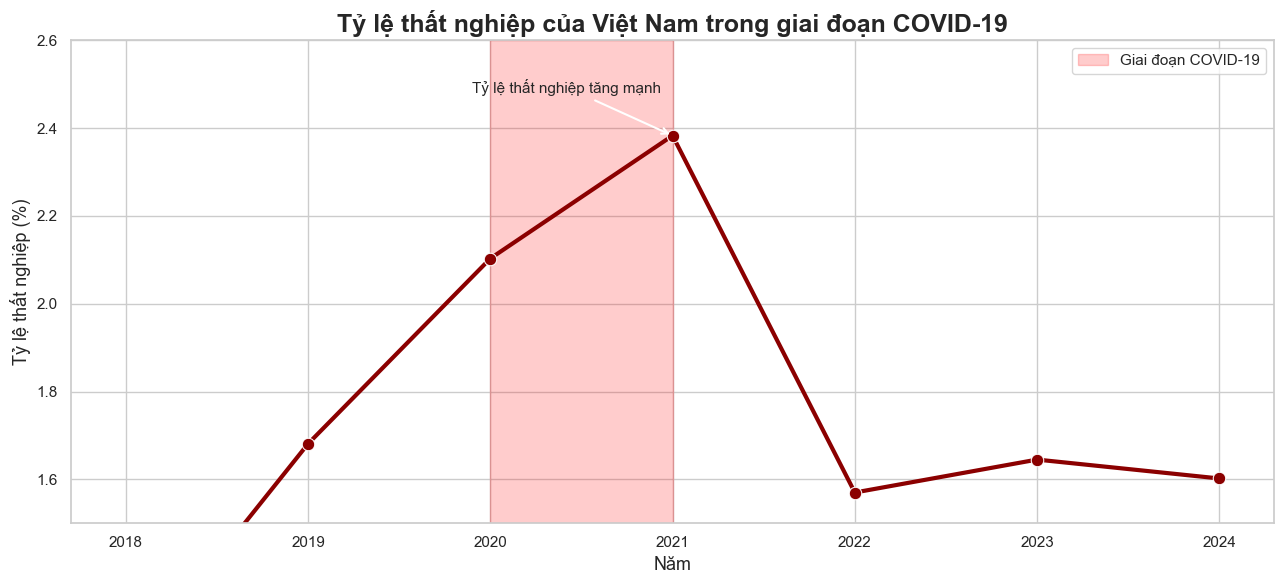

In [15]:
plt.figure(figsize=(13,6))
sns.lineplot(
    data=covid_df,
    x='year',
    y='unemployment',
    marker='o',
    linewidth=3,
    markersize=9,
    color='darkred'
)

# Highlight
plt.axvspan(
    2020,
    2021,
    alpha=0.2,
    color='red',
    label='Giai đoạn COVID-19'
)

# Annotation
plt.annotate(
    'Tỷ lệ thất nghiệp tăng mạnh',
    xy=(
        2021,
        covid_df.loc[
            covid_df['year'] == 2021,
            'unemployment'
        ].values[0]
    ),
    xytext=(2019.9, 2.48),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5
    ),
    fontsize=11
)

plt.title(
    'Tỷ lệ thất nghiệp của Việt Nam trong giai đoạn COVID-19',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Năm')
plt.ylabel('Tỷ lệ thất nghiệp (%)')
plt.xticks(covid_df['year'])
plt.ylim(1.5, 2.6)
plt.legend()
plt.tight_layout()
plt.show()

Tỷ lệ thất nghiệp tại Việt Nam tăng rõ rệt trong giai đoạn 2020–2021 dưới tác động của đại dịch COVID-19. Tỷ lệ thất nghiệp tăng từ khoảng 1.6% trước đại dịch lên gần 2.4% vào năm 2021, phản ánh sự suy giảm của thị trường lao động trong giai đoạn kinh tế bị gián đoạn.

Nguyên nhân chủ yếu đến từ việc nhiều doanh nghiệp phải thu hẹp hoạt động hoặc tạm ngừng sản xuất do các biện pháp giãn cách xã hội và gián đoạn chuỗi cung ứng. Các ngành như du lịch, dịch vụ và vận tải chịu ảnh hưởng nghiêm trọng nhất.

Sau năm 2022, tỷ lệ thất nghiệp giảm trở lại, cho thấy thị trường lao động bắt đầu phục hồi cùng với quá trình mở cửa nền kinh tế và khôi phục hoạt động sản xuất kinh doanh.

Mức độ kiểm soát của Chính phủ Việt Nam trong giai đoạn COVID-19

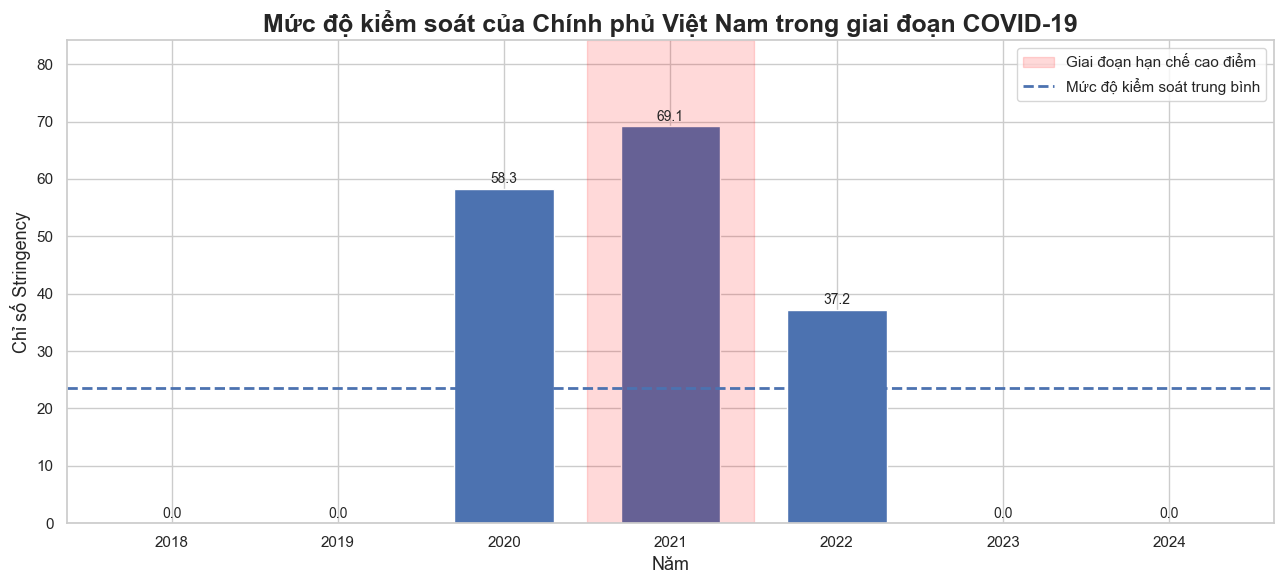

In [16]:
plt.figure(figsize=(13,6))
bars = plt.bar(
    covid_df['year'],
    covid_df['stringency_index'],
    width=0.6
)

# Highlight
plt.axvspan(
    2020.5,
    2021.5,
    alpha=0.15,
    color='red',
    label='Giai đoạn hạn chế cao điểm'
)

# đường tb
plt.axhline(
    covid_df['stringency_index'].mean(),
    linestyle='--',
    linewidth=2,
    label='Mức độ kiểm soát trung bình'
)

# gán giá trị
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Mức độ kiểm soát của Chính phủ Việt Nam trong giai đoạn COVID-19',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Năm')
plt.ylabel('Chỉ số Stringency')
plt.xticks(covid_df['year'])
plt.ylim(0, covid_df['stringency_index'].max() + 15)
plt.legend()
plt.tight_layout()
plt.show()

Biểu đồ cho thấy mức độ giãn cách xã hội tại Việt Nam tăng mạnh trong giai đoạn 2020–2021 và đạt đỉnh vào năm 2021 khi COVID-19 bùng phát mạnh. Chính phủ đã áp dụng nhiều biện pháp kiểm soát như hạn chế di chuyển, giãn cách xã hội và kiểm soát hoạt động kinh doanh nhằm hạn chế sự lây lan của dịch bệnh.

Mặc dù các biện pháp này góp phần kiểm soát dịch bệnh, chúng cũng tạo ra tác động tiêu cực lên hoạt động kinh tế và thị trường lao động trong ngắn hạn.

Sau năm 2022, Stringency Index giảm mạnh, phản ánh quá trình mở cửa trở lại và phục hồi của nền kinh tế Việt Nam.

Mối quan hệ giữa các biện pháp kiểm soát của chính phủ và tăng trưởng GDP

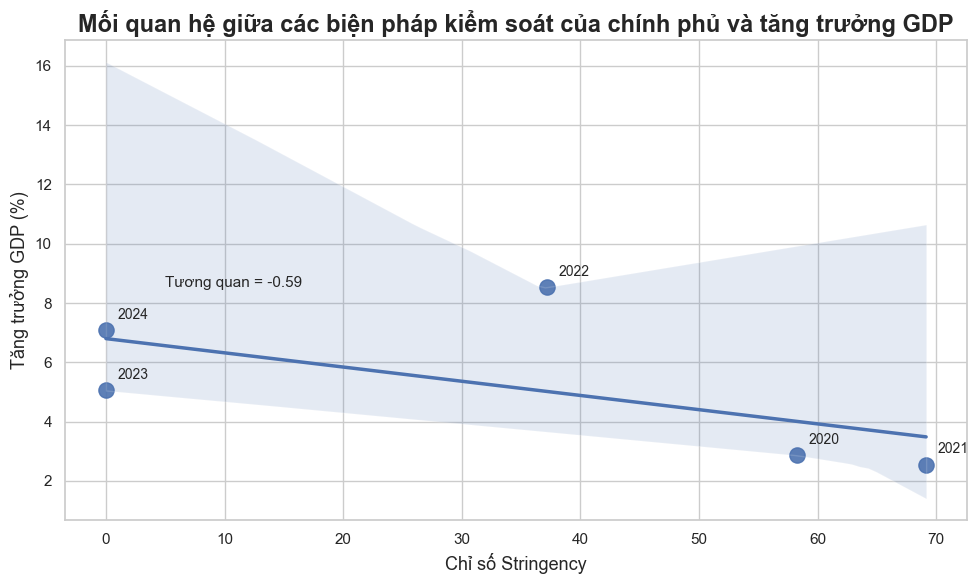

In [18]:
analysis_df = df[
    (df['year'] >= 2020) &
    (df['year'] <= 2024)
].copy()

plt.figure(figsize=(10,6))

sns.regplot(
    data=analysis_df,
    x='stringency_index',
    y='gdp_growth',
    scatter_kws={
        's':120,
        'alpha':0.9
    },
    line_kws={
        'linewidth':2.5
    }
)

# gán năm
for i in range(len(analysis_df)):

    plt.annotate(
        str(analysis_df['year'].iloc[i]),
        (
            analysis_df['stringency_index'].iloc[i],
            analysis_df['gdp_growth'].iloc[i]
        ),
        textcoords='offset points',
        xytext=(8,8),
        fontsize=10
    )

# Gtr tương quan
corr = analysis_df[
    ['stringency_index', 'gdp_growth']
].corr().iloc[0,1]

plt.text(
    5,
    analysis_df['gdp_growth'].max(),
    f'Tương quan = {corr:.2f}',
    fontsize=11
)
plt.title(
    'Mối quan hệ giữa các biện pháp kiểm soát của chính phủ và tăng trưởng GDP',
    fontsize=17,
    fontweight='bold'
)
plt.xlabel('Chỉ số Stringency')
plt.ylabel('Tăng trưởng GDP (%)')
plt.tight_layout()
plt.show()

In [10]:
corr, p = pearsonr(
    analysis_df['stringency_index'],
    analysis_df['gdp_growth']
)

print(corr, p)

-0.5917416057258269 0.2932012427143089


Biểu đồ cho thấy mối quan hệ tương quan âm giữa mức độ giãn cách xã hội và tăng trưởng GDP trong giai đoạn COVID-19 tại Việt Nam. Khi Chỉ số Stringency tăng lên, tăng trưởng GDP có xu hướng giảm, phản ánh tác động tiêu cực của các biện pháp hạn chế đối với hoạt động kinh tế.

Hệ số tương quan khoảng -0.59 cho thấy mức độ liên hệ âm ở mức tương đối giữa hai biến. Điều này phù hợp với bối cảnh giai đoạn 2020–2021 khi các biện pháp kiểm soát dịch bệnh nghiêm ngặt làm gián đoạn sản xuất, tiêu dùng và thương mại.

Tuy nhiên, giá trị p-value còn khá cao do số lượng quan sát hạn chế, vì vậy kết quả chủ yếu mang tính mô tả xu hướng hơn là khẳng định quan hệ nhân quả tuyệt đối.

HEATMAP Tương quan kinh tế vĩ mô trong giai đoạn COVID-19

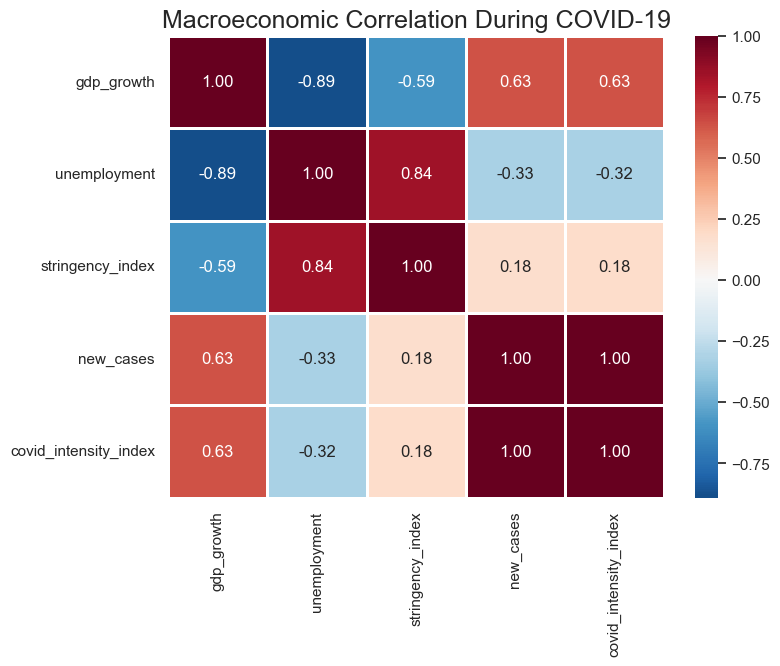

In [ ]:
corr_cols = [
    'gdp_growth',
    'unemployment',
    'stringency_index',
    'new_cases',
    'covid_intensity_index'
]

corr = analysis_df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    linewidths=1,
    fmt='.2f'
)

plt.title('Tương quan kinh tế vĩ mô trong giai đoạn COVID-19')

plt.show()

Ma trận tương quan cho thấy một số mối quan hệ đáng chú ý giữa các biến kinh tế vĩ mô trong giai đoạn COVID-19 tại Việt Nam.

GDP growth có tương quan âm mạnh với unemployment (-0.89), cho thấy khi tăng trưởng kinh tế suy giảm thì tỷ lệ thất nghiệp có xu hướng tăng lên. Bên cạnh đó, Stringency Index cũng có tương quan âm với GDP growth (-0.59) và tương quan dương với unemployment (0.84), phản ánh tác động tiêu cực của các biện pháp kiểm soát dịch bệnh lên hoạt động kinh tế và thị trường lao động.

Ngoài ra, số ca nhiễm mới và COVID intensity index có mối liên hệ với các biến kinh tế, cho thấy đại dịch đã tạo ra ảnh hưởng đáng kể đối với tăng trưởng và việc làm trong giai đoạn này.

Tuy nhiên, do số lượng quan sát trong giai đoạn COVID-19 còn hạn chế, các hệ số tương quan chủ yếu phản ánh xu hướng mô tả hơn là khẳng định quan hệ nhân quả tuyệt đối.

BEFORE / DURING / AFTER COVID

C:\Users\ACER\AppData\Local\Temp\ipykernel_20184\92384546.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_20184\92384546.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


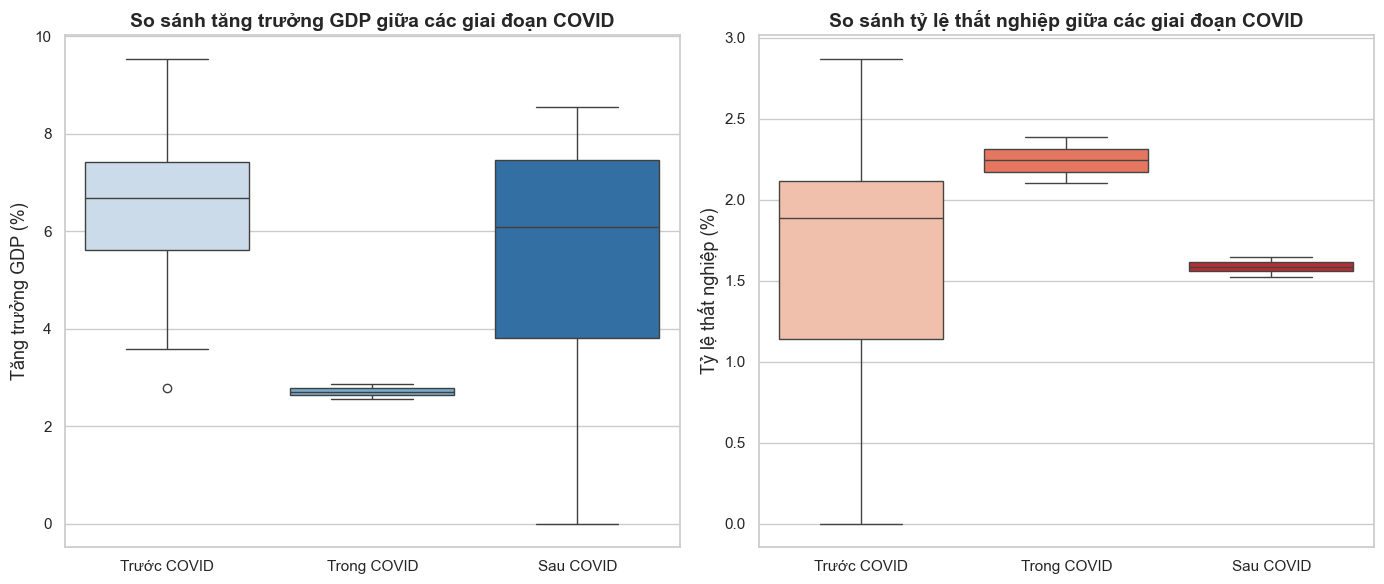

In [19]:
# Tạo các giai đoạn COVID
conditions = [
    df['year'] <= 2019,
    (df['year'] >= 2020) & (df['year'] <= 2021),
    df['year'] >= 2022
]

choices = [
    'Trước COVID',
    'Trong COVID',
    'Sau COVID'
]

df['covid_period'] = np.select(
    conditions,
    choices,
    default='Không xác định'
)

# Tạo biểu đồ so sánh song song
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# So sánh tăng trưởng GDP
sns.boxplot(
    data=df,
    x='covid_period',
    y='gdp_growth',
    ax=axes[0],
    palette='Blues'
)

axes[0].set_title(
    'So sánh tăng trưởng GDP giữa các giai đoạn COVID',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('')
axes[0].set_ylabel('Tăng trưởng GDP (%)')

# So sánh tỷ lệ thất nghiệp
sns.boxplot(
    data=df,
    x='covid_period',
    y='unemployment',
    ax=axes[1],
    palette='Reds'
)

axes[1].set_title(
    'So sánh tỷ lệ thất nghiệp giữa các giai đoạn COVID',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('')
axes[1].set_ylabel('Tỷ lệ thất nghiệp (%)')

plt.tight_layout()

plt.show()

Trong giai đoạn COVID-19 (2020–2021), tăng trưởng GDP giảm mạnh xuống mức thấp nhất trong ba giai đoạn, trong khi tỷ lệ thất nghiệp tăng lên rõ rệt, phản ánh tác động tiêu cực của đại dịch lên hoạt động kinh tế và thị trường lao động.

Sau năm 2022, GDP tăng trở lại và tỷ lệ thất nghiệp giảm dần, cho thấy nền kinh tế Việt Nam đã phục hồi tương đối tích cực sau cú sốc COVID-19 nhờ quá trình mở cửa trở lại và phục hồi hoạt động sản xuất kinh doanh. Tuy nhiên, tăng trưởng kinh tế giai đoạn hậu COVID vẫn còn biến động, cho thấy nền kinh tế chưa hoàn toàn quay lại trạng thái ổn định như trước đại dịch.

STRUCTURAL BREAK

In [20]:
before_covid = df[df['year'] < 2020]
during_covid = df[df['year'] >= 2020]

print('Tăng trưởng GDP trung bình trước COVID:',
      before_covid['gdp_growth'].mean())

print('Tăng trưởng GDP trung bình trong COVID:',
      during_covid['gdp_growth'].mean())

print('Tỷ lệ thất nghiệp trung bình trước COVID:',
      before_covid['unemployment'].mean())

print('Tỷ lệ thất nghiệp trung bình trong COVID:',
      during_covid['unemployment'].mean())

Tăng trưởng GDP trung bình trước COVID: 6.54507150972045
Tăng trưởng GDP trung bình trong COVID: 4.352142264008735
Tỷ lệ thất nghiệp trung bình trước COVID: 1.5732285714285716
Tỷ lệ thất nghiệp trung bình trong COVID: 1.8043333333333333


Kết quả cho thấy có sự thay đổi đáng kể của các chỉ số kinh tế vĩ mô sau năm 2020. Tăng trưởng GDP trung bình giảm từ khoảng 6.55% trước COVID xuống còn khoảng 4.35% trong giai đoạn COVID-19, trong khi tỷ lệ thất nghiệp trung bình tăng từ khoảng 1.57% lên 1.80%.

Sự thay đổi này phản ánh tác động mạnh của đại dịch đối với hoạt động kinh tế và thị trường lao động tại Việt Nam. Điều này cho thấy năm 2020 có thể được xem là một structural break đối với nền kinh tế Việt Nam khi xu hướng của các biến kinh tế thay đổi rõ rệt sau đại dịch.

KEY FINDINGS

Finding 1
COVID-19 tạo ra cú sốc kinh tế rõ rệt tại Việt Nam trong giai đoạn 2020–2021, thể hiện qua sự suy giảm mạnh của tăng trưởng GDP và sự gia tăng của tỷ lệ thất nghiệp.

Finding 2
Stringency Index có mối quan hệ âm với tăng trưởng GDP và mối quan hệ dương với tỷ lệ thất nghiệp, cho thấy các biện pháp kiểm soát dịch bệnh nghiêm ngặt đã tác động tiêu cực đến hoạt động kinh tế và thị trường lao động trong ngắn hạn.

Finding 3
Ma trận tương quan cho thấy GDP growth có tương quan âm mạnh với unemployment, phản ánh xu hướng thất nghiệp gia tăng khi tăng trưởng kinh tế suy giảm trong giai đoạn COVID-19.

Finding 4
Sau năm 2022, nền kinh tế Việt Nam cho thấy dấu hiệu phục hồi khi tăng trưởng GDP tăng trở lại và tỷ lệ thất nghiệp giảm dần nhờ quá trình mở cửa nền kinh tế và phục hồi hoạt động sản xuất kinh doanh.

Finding 5
Kết quả phân tích before/during/after COVID và structural break cho thấy năm 2020 có thể được xem là một bước ngoặt kinh tế quan trọng khi hành vi của các chỉ số kinh tế vĩ mô thay đổi rõ rệt sau đại dịch.

LIMITATIONS

Dataset sử dụng dữ liệu theo năm nên số lượng quan sát còn hạn chế, đặc biệt trong giai đoạn COVID-19.
Phân tích chưa phản ánh được biến động ngắn hạn theo quý hoặc theo tháng của nền kinh tế và thị trường lao động.
Một số biến liên quan đến COVID-19 như Stringency Index và số ca nhiễm chỉ thực sự có ý nghĩa từ năm 2020.
Mô hình phân tích chưa kiểm soát toàn bộ các yếu tố kinh tế vĩ mô có thể ảnh hưởng đến tăng trưởng GDP và thất nghiệp.
Structural break analysis mới dừng ở mức so sánh mô tả và chưa sử dụng các kiểm định thống kê chuyên sâu.

CONCLUSION

Phân tích cho thấy COVID-19 đã tác động tiêu cực rõ rệt đến nền kinh tế Việt Nam trong giai đoạn 2020–2021 khi tăng trưởng GDP suy giảm và tỷ lệ thất nghiệp gia tăng. Stringency Index có mối quan hệ âm với GDP growth và quan hệ dương với unemployment, phản ánh tác động của các biện pháp kiểm soát dịch bệnh lên hoạt động kinh tế.

Tuy nhiên, sau năm 2022, nền kinh tế Việt Nam cho thấy dấu hiệu phục hồi khi GDP tăng trở lại và tỷ lệ thất nghiệp giảm dần nhờ quá trình mở cửa và phục hồi hoạt động sản xuất kinh doanh.